## Ridge Regression (L2 Regularization)

Ridge Regression is an extension of Linear Regression that adds a penalty term to reduce model complexity and prevent overfitting.

### Linear Regression Loss Function
$$
Loss = RSS = \sum (y_i - \hat{y}_i)^2
$$
### Ridge Regression Loss Function
$$
Loss = RSS + \lambda \sum \beta_j^2
$$
where:
- RSS = Residual Sum of Squares
- $(\lambda)$ = Regularization strength
- $(\beta_j)$ = Model coefficients

---

### Why Ridge is Better than Linear Regression

Linear Regression:
- Tries to fit the training data as closely as possible.
- Can overfit when there are many features.
- Large coefficients may make the model sensitive to noise.

Ridge Regression:
- Penalizes large coefficients.
- Shrinks coefficients toward zero.
- Produces a simpler and more stable model.
- Usually generalizes better on unseen data.

---

### Effect on Model Complexity

As $(\lambda)$ increases:

- Coefficients become smaller.
- Model complexity decreases.
- Variance decreases.
- Bias increases slightly.

This creates a better balance between underfitting and overfitting.

---

### Important Note

- Ridge uses **L2 Regularization** $(\beta^2)$.
- Ridge reduces coefficients but does **not** make them exactly zero.
- Therefore, Ridge does **not perform feature selection**.

If you want automatic feature selection, use **Lasso Regression (L1 Regularization)**.

---

### Main Intuition

Linear Regression:
> Fit the data as closely as possible.

Ridge Regression:
> Fit the data well, but keep the coefficients small to avoid overfitting.

In [33]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt  

from sklearn.datasets import load_diabetes
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , Ridge # Topic
from sklearn.metrics import r2_score,mean_absolute_error


In [4]:
data = load_diabetes()

In [23]:
# datasets - Description
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [18]:
x = data.data
y = data.target

In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
lr = LinearRegression()

lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = lr.predict(x_test)

In [22]:
print('R2 Score :',r2_score(y_test,y_pred))
print('RMSE Score :',np.sqrt(mean_absolute_error(y_test,y_pred)))

R2 Score : 0.45260276297191937
RMSE Score : 6.541719550668612


In [25]:
R = Ridge(alpha=0.0001)

In [26]:
R.fit(x_train,y_train) 
y_pred2 = R.predict(x_test)

In [27]:
print('R2 Score (Ridge):',r2_score(y_test,y_pred2))
print('RMSE Score (Ridge):',np.sqrt(mean_absolute_error(y_test,y_pred2)))

R2 Score (Ridge): 0.452699815422011
RMSE Score (Ridge): 6.541782894929501


In [28]:
# we are achieve same accuary  , using Ridge 

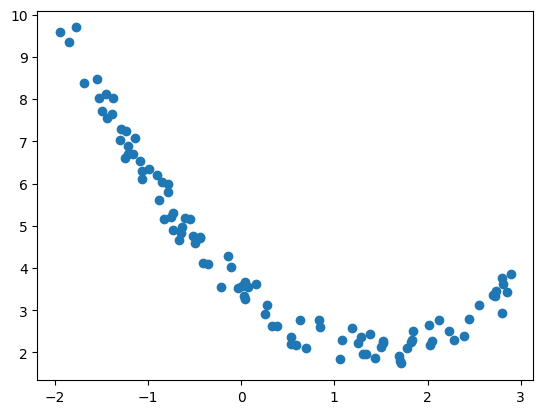

In [30]:
m = 100 
x1 = 5 * np.random.rand(m,1) - 2 
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.rand(m,1) 

plt.scatter(x1,x2) 
plt.show()

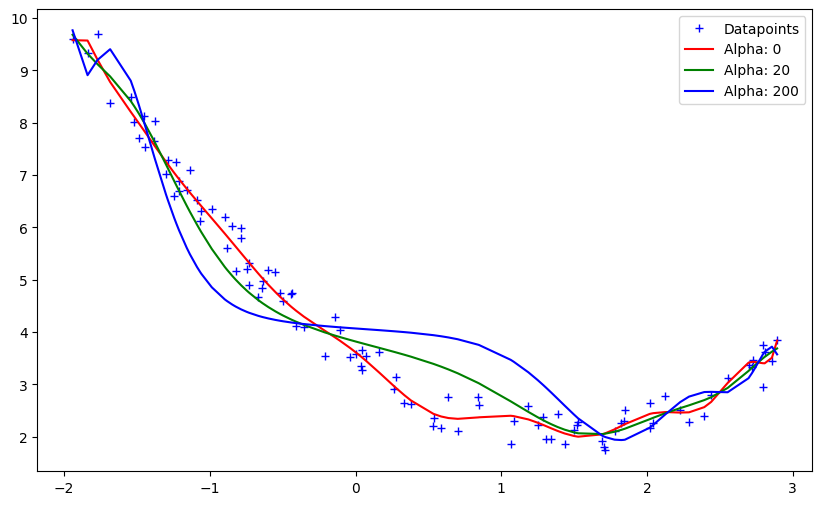

In [36]:

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

In [37]:
# red = Overfit 
# Green = Balanced 
# Blue = Underfit